## ¿Qué es la regresión lineal?

La regresión lineal es un método estadístico utilizado para analizar la relación entre dos variables numéricas. 
Este método busca encontrar una línea recta que represente la tendencia de los datos y permita realizar predicciones.

En este modelo se utiliza una variable independiente (X) para predecir el valor de una variable dependiente (Y).

La ecuación general de la regresión lineal es:

y = mx + b

donde:

m = pendiente de la recta  
b = intersección con el eje Y  

Este modelo es ampliamente utilizado en análisis de datos, predicción de valores y aprendizaje automático.

Creamos un conjunto de datos que en proyectos reales se sacaran de alguna base de datos.

La cargamos utilizando pandas y su funcion read_csv en la variable datos.

In [ ]:
import pandas as pd
datos = pd.read_csv("celsuis.csv")
import pandas as pd
import seaborn as sb
from sklearn.linear_model import LinearRegression

    

Obtuvimos algunos metadatos para verlo

In [77]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Celsius      7 non-null      int64  
 1    Fahrenheit  7 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 244.0 bytes


In [78]:
datos.head()

,Celsius,Fahrenheit
0,-40,-40.0
1,-10,14.0
2,0,32.0
3,8,46.4
4,15,59.0


Uilizamos seaborn para visualizar la relacion entre los grados celsius y fahrenheit 

<Axes: xlabel='Celsius', ylabel=' Fahrenheit'>

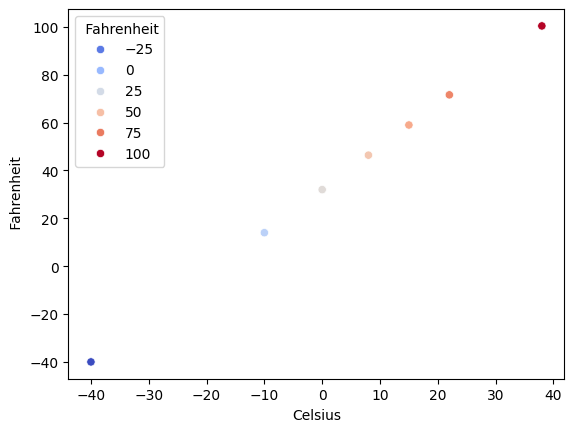

In [79]:
import seaborn as sb

sb.scatterplot(x="Celsius", y=" Fahrenheit", data=datos,hue=" Fahrenheit", palette="coolwarm")

Separamos las caracteristicas de la etiqueta 

In [80]:
#Caracteristicas (X), etiqueta (y)
X = datos["Celsius"]
y = datos[" Fahrenheit"]

In [81]:
y

0    -40.0
1     14.0
2     32.0
3     46.4
4     59.0
5     71.6
6    100.4
Name:  Fahrenheit, dtype: float64

In [82]:
X

0   -40
1   -10
2     0
3     8
4    15
5    22
6    38
Name: Celsius, dtype: int64

Hicimos una pequeña transformacion necesaria para poder entrenar y predecir.   

In [83]:
X.values
#[-40, -10, 0, 8 ...]
#[[-40], [-10], [0], [8], ...]

X_procesada =X.values.reshape(-1,1)
y_procesada =y.values.reshape(-1,1)

Se crea el modelo.

In [84]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()

Lo entrenamos con los datos.

In [85]:
#Entrenamiento
modelo.fit(X_procesada, y_procesada)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Se realizan las predicciones.

In [86]:
celsius = 7900
prediccion = modelo.predict([[celsius]])
modelo.predict([[7900]])
print(f"{celsius} grados celsius son {prediccion} grados fahrenheit")

7900 grados celsius son [[14252.]] grados fahrenheit


In [87]:
modelo.score(X_procesada, y_procesada)

1.0

In [88]:
import sklearn
print(sklearn.__version__)

1.8.0
